<a href="https://colab.research.google.com/github/cyeef/Data-Science-Portfolio-C21-/blob/main/Projects/Project-3/SQL_1_Chinook_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project SQL: Data Discovery with the Chinook Database

Welcome to your first major hands-on data exploration project. In this assignment, you will be stepping into the role of a data analyst querying the Chinook database: a sample dataset representing a digital media store, complete with information about artists, albums, tracks, customers, and business sales.

The core objective of this project is to transition you from simply writing code to thinking like a data scientist. To do that, our journey follows a deliberate, four-fold progression:



### Phase 1. Master the Mechanics (Get Familiar with SQL)



Before you can extract deep insights, you need to speak the language. You will start by practicing the fundamental mechanics of SQL using the SQL statements below: learning how to filter data, join tables, group metrics, and aggregate numbers. Think of this as learning how to move around the data environment smoothly.  As a starting point, pick a single table and answer the "How many ...?" questions using SQL.  Then repeat the process for each table.



### Phase 2. Map the Terrain (Get Familiar with the Data)



Data never exists in a vacuum. By writing queries, you will uncover the shape, structure, and quirks of the Chinook dataset. Again, using the SQL statements below, you'll learn how the tables relate to one another, what a single row represents in different contexts, and where specific types of information live.  Here's where you should get familiar with the ERD and join tables in various ways.



### Phase 3. Answer Guided Questions



Once you know the syntax and understand the data structure, you will put your skills to work solving specific business problems. Below are sets of explicit questions to answer using SQL. This phase mimics standard reporting: you are handed a specific prompt, and your job is to translate that prompt into an accurate, data-driven answer.

Here are some practice questions:
- https://github.com/LucasMcL/15-sql_queries_02-chinook/blob/master/README.md
- [Using the R language]( https://rpubs.com/enext777/636199 )
- [Search Google]( https://www.google.com/search?q=chinook+database+questions )
- Ask AI to generate some questions for you.  Be sure to mention the Chinook data set.




### Phase 4. Ask and Answer Your Own Questions


This final phase is the most critical part of the project. The true hallmark of a great data scientist isn't just answering the questions you're handed; it's having the curiosity and intuition to formulate your own questions.

You are tasked with looking at the Chinook dataset, generating your own original hypotheses or business questions, and writing the SQL required to answer them.

Demonstrate that you know SQL fundamentals by posting a question for each SQL statement below and then using the SQL statement to answer you question.

You will use the material from this phase for the presentation.



## Why This Matters: The Path to Your Capstone


Learning to ask your own questions is the exact skill you will rely on for your final capstone project. In your capstone, you will choose a dataset from your own field of interest. No one will hand you a list of prompts or a guide telling you what to look for.

Use this project as your sandbox. Mastering the ability to interrogate a database now will give you the framework you need to discover meaningful, independent insights in your capstone later.



## Chinook data set

See the lecture on SQLite3 using the Chinook data set to set up the software, database, and tables, as well as for the links to ancillary information about the data set.


In [1]:
%%bash
# Install the sqlite package for Ubuntu-2ubuntu0.6_amd64.
apt-get -qq update
# Download the Chinook sqlite database   /libsqlite3-dev_3.37.2
apt-get -qq install -y sqlite3  # -qq reduces install logs, tells prompts go ahead a auto yes
# load the zip file and unzip
[ -f chinook.zip ] || curl -s -O https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip
unzip -u chinook.zip
ls -la chinook.db

Archive:  chinook.zip
-rw-r--r-- 1 root root 884736 Nov 29  2015 chinook.db


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## Use SQL queries to pull specific information

Do NOT pull all the data and then filter using DataFrame methods.  The initial purpose is to get familiar with SQL.




In [2]:
import sqlite3 as db
import pandas as pd
from contextlib import closing

### Create the 11 tables in the dataset.

In [3]:
tables = {}
with closing(db.connect("chinook.db")) as db_con:
    names = pd.read_sql_query(
        "SELECT name FROM sqlite_master "
        "WHERE type='table' AND name NOT LIKE 'sqlite_%' "
        "ORDER BY name;",
        db_con
    )["name"].tolist()

    for t in names:
        tables[t] = pd.read_sql_query(f'SELECT * FROM "{t}"', db_con)

for name, frame in tables.items():
    print(f"{name:16s} {frame.shape}")

albums           (347, 3)
artists          (275, 2)
customers        (59, 13)
employees        (8, 15)
genres           (25, 2)
invoice_items    (2240, 5)
invoices         (412, 9)
media_types      (5, 2)
playlist_track   (8715, 2)
playlists        (18, 2)
tracks           (3503, 9)


Convert invoices.InvoiceDate, employees.BirthDate and employee.HireDate to datetime objects not strings so Parquet can keep them in the new format and not strings

In [4]:
# invoices: InvoiceDate text -> datetime
tables["invoices"]["InvoiceDate"] = pd.to_datetime(tables["invoices"]["InvoiceDate"])

# employees: BirthDate and HireDate text -> datetime
tables["employees"]["BirthDate"] = pd.to_datetime(tables["employees"]["BirthDate"])
tables["employees"]["HireDate"]  = pd.to_datetime(tables["employees"]["HireDate"])

# confirm the conversions
print("invoices.InvoiceDate:", tables["invoices"]["InvoiceDate"].dtype)
print("employees.BirthDate: ", tables["employees"]["BirthDate"].dtype)
print("employees.HireDate:  ", tables["employees"]["HireDate"].dtype)

invoices.InvoiceDate: datetime64[ns]
employees.BirthDate:  datetime64[ns]
employees.HireDate:   datetime64[ns]


### Create a file folder name chinook, tables to parquet and and confirm folder has 11 files.

In [5]:
import os

# make the folder (ok if it already exists)
os.makedirs("chinook", exist_ok=True)

# write each table to its own parquet file inside chinook/
for name, frame in tables.items():
    path = f"chinook/{name}.parquet"
    frame.to_parquet(path)
    print(f"wrote {path}  {frame.shape}")

# confirm the folder has 11 files
print("\nFiles in chinook/:", len(os.listdir("chinook")))
print(sorted(os.listdir("chinook")))

wrote chinook/albums.parquet  (347, 3)
wrote chinook/artists.parquet  (275, 2)
wrote chinook/customers.parquet  (59, 13)
wrote chinook/employees.parquet  (8, 15)
wrote chinook/genres.parquet  (25, 2)
wrote chinook/invoice_items.parquet  (2240, 5)
wrote chinook/invoices.parquet  (412, 9)
wrote chinook/media_types.parquet  (5, 2)
wrote chinook/playlist_track.parquet  (8715, 2)
wrote chinook/playlists.parquet  (18, 2)
wrote chinook/tracks.parquet  (3503, 9)

Files in chinook/: 11
['albums.parquet', 'artists.parquet', 'customers.parquet', 'employees.parquet', 'genres.parquet', 'invoice_items.parquet', 'invoices.parquet', 'media_types.parquet', 'playlist_track.parquet', 'playlists.parquet', 'tracks.parquet']


### Push folder to Huggingface DataScience 21, past token in input box.

In [6]:
from huggingface_hub import login, HfApi
login()   # paste my token when the box appears

api = HfApi()
repo_id = "RaayGunz/Data_Science-21"
api.create_repo(repo_id=repo_id, repo_type="dataset", exist_ok=True)

api.upload_folder(
    folder_path="chinook",
    path_in_repo="chinook",
    repo_id=repo_id,
    repo_type="dataset",
)
print("Pushed to:", f"https://huggingface.co/datasets/{repo_id}")

No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to: https://huggingface.co/datasets/RaayGunz/Data_Science-21


### Checking to see if files are readable

In [41]:
import pandas as pd
url = "hf://datasets/RaayGunz/Data_Science-21/chinook/tracks.parquet"
df = pd.read_parquet(url)
print(df.shape)   #checking shape

(3503, 9)


### Identifying what is in the database - there are 11 tables, albums, artist, customer etc.

In [7]:
 # 11 tables # the internal catalogue of SQLITE - help
# excluding sqllite indexing, triggers and views # sorting by alphabetical order without modificaiton
query = """
  SELECT name
  FROM sqlite_master
  WHERE type = 'table' AND name NOT LIKE 'sqlite_%'
  ORDER BY name;
"""
with closing(db.connect("chinook.db")) as db_con:
    tables = pd.read_sql_query(query, db_con)

tables

,name
0,albums
1,artists
2,customers
3,employees
4,genres
5,invoice_items
6,invoices
7,media_types
8,playlist_track
9,playlists


### Basic Queries


#### SELECT (with * and with column names)


### Identifying the all the column names in media type using SELECT wildcard * - MOEG, AAC, MEPEG 4

In [8]:
query = """

   SELECT *

  FROM media_types

  LIMIT 10;
"""
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df

,MediaTypeId,Name
0,1,MPEG audio file
1,2,Protected AAC audio file
2,3,Protected MPEG-4 video file
3,4,Purchased AAC audio file
4,5,AAC audio file


### Call table Media_Type and Media_Type Id with corresponding format types in row names

In [9]:
query = """

  Select MediaTypeId, Name

  FROM media_types

  LIMIT 10;

"""

with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)

df

,MediaTypeId,Name
0,1,MPEG audio file
1,2,Protected AAC audio file
2,3,Protected MPEG-4 video file
3,4,Purchased AAC audio file
4,5,AAC audio file


#### WHERE


### Query table invoices and use Select * (wildcard) to identify the names of columns - limited 10 and closed query at the end of the query there are 9 columns InvoiceID, customer id invoice date, billing rows and total. Limit 10 starts at 0.

In [10]:
query = """

   SELECT *

  FROM invoices

  LIMIT 10;
"""
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2009-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2009-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,3,8,2009-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94
3,4,14,2009-01-06 00:00:00,8210 111 ST NW,Edmonton,AB,Canada,T6G 2C7,8.91
4,5,23,2009-01-11 00:00:00,69 Salem Street,Boston,MA,USA,2113,13.86
5,6,37,2009-01-19 00:00:00,Berger Straße 10,Frankfurt,None,Germany,60316,0.99
6,7,38,2009-02-01 00:00:00,Barbarossastraße 19,Berlin,None,Germany,10779,1.98
7,8,40,2009-02-01 00:00:00,"8, Rue Hanovre",Paris,None,France,75002,1.98
8,9,42,2009-02-02 00:00:00,"9, Place Louis Barthou",Bordeaux,None,France,33000,3.96
9,10,46,2009-02-03 00:00:00,3 Chatham Street,Dublin,Dublin,Ireland,None,5.94


### Used Select to call Invoice date columns and where in Invvoicedate to determine which date begin in 2010 - limited 10.  Dates start with Year month, and day with time equaling 00.00.00,

In [11]:
#

query = """

  SELECT InvoiceDate

  FROM invoices

  WHERE  Invoicedate LIKE '2010%'

  LIMIT 10;

"""
with closing(db.connect("chinook.db")) as db_con:
    df = pd.read_sql_query(query, db_con)
df

,InvoiceDate
0,2010-01-08 00:00:00
1,2010-01-08 00:00:00
2,2010-01-09 00:00:00
3,2010-01-10 00:00:00
4,2010-01-13 00:00:00
5,2010-01-18 00:00:00
6,2010-01-26 00:00:00
7,2010-02-08 00:00:00
8,2010-02-08 00:00:00
9,2010-02-09 00:00:00


Used string format time which temporary converts the date time format - only used to practice in this exercise - not good for large databases - slows the query.  Extracted the year 2013 - tried 2015 but query returned no values.  Wanted to know what the last year in the table was - answer 2013

In [12]:
query = """

  SELECT InvoiceDate

  FROM invoices

  WHERE  strftime('%Y', Invoicedate) = "2013"

  LIMIT 15;

"""
with closing(db.connect("chinook.db")) as db_con:
    df = pd.read_sql_query(query, db_con)
df

,InvoiceDate
0,2013-01-02 00:00:00
1,2013-01-07 00:00:00
2,2013-01-15 00:00:00
3,2013-01-28 00:00:00
4,2013-01-28 00:00:00
5,2013-01-29 00:00:00
6,2013-01-30 00:00:00
7,2013-02-02 00:00:00
8,2013-02-07 00:00:00
9,2013-02-15 00:00:00


#### AND


### Select for Billing city, custoemr id, and total - from invoices table, wanted to dettermine how many customer ids in Stuttgarts between the customer Id range of 20 and 37 = result = no customers in Stuttgart with customer IDs betwen 20 and 37

In [13]:
query = """

  SELECT BillingCity, CustomerId, TOTAL

  FROM invoices

  WHERE  BillingCity = 'Stuttgart'

    AND CustomerId Between 20 AND 37

  LIMIT 15;

"""
with closing(db.connect("chinook.db")) as db_con:
    df = pd.read_sql_query(query, db_con)
df

,BillingCity,CustomerId,Total


### See how many customers in range of 4 to 20 who spent more than $5.00 dollars

In [14]:
query = """

  SELECT BillingCity, CustomerId, TOTAL

  FROM invoices

  WHERE CustomerId Between 4 AND 100

  AND TOTAL > 2.00

  LIMIT 25;

"""
with closing(db.connect("chinook.db")) as db_con:
    df = pd.read_sql_query(query, db_con)
df

,BillingCity,CustomerId,Total
0,Oslo,4,3.96
1,Oslo,4,5.94
2,Oslo,4,15.86
3,Oslo,4,8.91
4,Prague,5,3.96
5,Prague,5,5.94
6,Prague,5,16.86
7,Prague,5,8.91
8,Prague,6,8.91
9,Prague,6,3.96


#### OR


### Looking to see if the billing city is Stuttgart or Frankfurt or the total invoice is 15.00 dollars or more

In [15]:
query = """

  SELECT BillingCity,  TOTAL

  FROM invoices

  WHERE  BillingCity = 'Stuttgart' OR 'Frankfurt'

    OR TOTAL >= 15.00

  LIMIT 15;

"""
with closing(db.connect("chinook.db")) as db_con:
    df = pd.read_sql_query(query, db_con)
df

,BillingCity,Total
0,Stuttgart,1.98
1,Stuttgart,13.86
2,Stuttgart,8.91
3,Santiago,17.91
4,Vienne,18.86
5,Budapest,21.86
6,Chicago,15.86
7,Dublin,21.86
8,Stuttgart,1.98
9,Madison,18.86


#### LIKE (with % or _ wildcard)


### Looking at billing state and total where the state name has an A result CA, MA and WA had invoices more than 8 dollars returned results didn't show anything equal to 8.00

In [16]:
query = """

  SELECT BillingState, TOTAL

  FROM invoices

  WHERE   BillingState LIKE '_A'
   AND TOTAL >= 8.00

  LIMIT 15;

"""
with closing(db.connect("chinook.db")) as db_con:
    df = pd.read_sql_query(query, db_con)
df

,BillingState,Total
0,MA,13.86
1,CA,13.86
2,MA,8.91
3,CA,8.91
4,CA,13.86
5,CA,13.86
6,CA,8.91
7,CA,8.91
8,WA,13.86
9,WA,10.91


#### BETWEEN


Using table PLAYSLIST

In [17]:
query = '''

SELECT *

FROM playlists

LIMIT 25;

'''
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)

df

,PlaylistId,Name
0,1,Music
1,2,Movies
2,3,TV Shows
3,4,Audiobooks
4,5,90’s Music
5,6,Audiobooks
6,7,Movies
7,8,Music
8,9,Music Videos
9,10,TV Shows


### Used BETWEEN to playlist id to find names like '%al%' for classical found 5 results

In [18]:
query = '''

  SELECT PlaylistId, Name

  FROM playlists

  WHERE PlaylistId Between 4 AND 25

  AND Name  LIKE '%al%'


  LIMIT 25;

  '''
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)

df

,PlaylistId,Name
0,12,Classical
1,13,Classical 101 - Deep Cuts
2,14,Classical 101 - Next Steps
3,15,Classical 101 - The Basics
4,17,Heavy Metal Classic


#### LIMIT



LOOKED TO SEE WHAT PlaylistID  was added last out of the table - used limit and order by to filter the results - PlaylistId and Name 'On-The-Go 1'

In [19]:
query = '''

  SELECT PlaylistId, Name

  FROM playlists

  ORDER BY PlaylistId DESC


  LIMIT 30;

  '''
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)

df

,PlaylistId,Name
0,18,On-The-Go 1
1,17,Heavy Metal Classic
2,16,Grunge
3,15,Classical 101 - The Basics
4,14,Classical 101 - Next Steps
5,13,Classical 101 - Deep Cuts
6,12,Classical
7,11,Brazilian Music
8,10,TV Shows
9,9,Music Videos


Created  mismatched table

### Sorting and Grouping


#### ORDER BY


In [20]:
query = '''

  SELECT PlaylistId, NAME

  FROM playlists

  ORDER BY NAME ASC


  LIMIT 30;

  '''
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)

df

,PlaylistId,Name
0,5,90’s Music
1,4,Audiobooks
2,6,Audiobooks
3,11,Brazilian Music
4,12,Classical
5,13,Classical 101 - Deep Cuts
6,14,Classical 101 - Next Steps
7,15,Classical 101 - The Basics
8,16,Grunge
9,17,Heavy Metal Classic


#### DISTINCT


In [21]:
query = '''

SELECT DISTINCT Name

FROM playlists

ORDER BY Name ASC

LIMIT 15;

'''
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)

df

,Name
0,90’s Music
1,Audiobooks
2,Brazilian Music
3,Classical
4,Classical 101 - Deep Cuts
5,Classical 101 - Next Steps
6,Classical 101 - The Basics
7,Grunge
8,Heavy Metal Classic
9,Movies


#### GROUP BY



In [22]:
query = '''

SELECT Name, COUNT(PlaylistId) AS NumberOfPlaylists

FROM playlists

GROUP BY Name

LIMIT 15;

'''
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)

df

,Name,NumberOfPlaylists
0,90’s Music,1
1,Audiobooks,2
2,Brazilian Music,1
3,Classical,1
4,Classical 101 - Deep Cuts,1
5,Classical 101 - Next Steps,1
6,Classical 101 - The Basics,1
7,Grunge,1
8,Heavy Metal Classic,1
9,Movies,2


### Aggregates


### Using Cutomers table

In [23]:
query = """

   SELECT *

  FROM customers

  LIMIT 10;
"""
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,None,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,+49 0711 2842222,None,leonekohler@surfeu.de,5
2,3,François,Tremblay,None,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,None,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,None,Ullevålsveien 14,Oslo,None,Norway,0171,+47 22 44 22 22,None,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,None,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4
5,6,Helena,Holý,None,Rilská 3174/6,Prague,None,Czech Republic,14300,+420 2 4177 0449,None,hholy@gmail.com,5
6,7,Astrid,Gruber,None,"Rotenturmstraße 4, 1010 Innere Stadt",Vienne,None,Austria,1010,+43 01 5134505,None,astrid.gruber@apple.at,5
7,8,Daan,Peeters,None,Grétrystraat 63,Brussels,None,Belgium,1000,+32 02 219 03 03,None,daan_peeters@apple.be,4
8,9,Kara,Nielsen,None,Sønder Boulevard 51,Copenhagen,None,Denmark,1720,+453 3331 9991,None,kara.nielsen@jubii.dk,4
9,10,Eduardo,Martins,Woodstock Discos,"Rua Dr. Falcão Filho, 155",São Paulo,SP,Brazil,01007-010,+55 (11) 3033-5446,+55 (11) 3033-4564,eduardo@woodstock.com.br,4


#### MAX


### Determine the highest value of customer id using max

In [24]:
query = '''

SELECT MAX(CustomerId) AS HighestCustomerId

FROM customers


'''

with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df

,HighestCustomerId
0,59


#### MIN


### Use Table tracks

In [25]:
query = """

   SELECT *

  FROM tracks

  LIMIT 10;
"""
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,None,342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99
5,6,Put The Finger On You,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",205662,6713451,0.99
6,7,Let's Get It Up,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",233926,7636561,0.99
7,8,Inject The Venom,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",210834,6852860,0.99
8,9,Snowballed,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",203102,6599424,0.99
9,10,Evil Walks,1,1,1,"Angus Young, Malcolm Young, Brian Johnson",263497,8611245,0.99


### using min to find the min millisecond and byte values

In [26]:
query = '''

SELECT MIN(Milliseconds) AS LowestMilliseconds,

   MIN(Bytes) AS LowestBytes

FROM tracks;



'''

with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df

,LowestMilliseconds,LowestBytes
0,1071,38747


### Using min and name to fine the actual track name that is the minimum in milliseconds and minimum in bytes

In [27]:
query = '''

SELECT TrackId, Name, Milliseconds, Bytes

FROM tracks

WHERE Milliseconds = (SELECT MIN(Milliseconds) FROM tracks);

'''
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df

,TrackId,Name,Milliseconds,Bytes
0,2461,É Uma Partida De Futebol,1071,38747


#### SUM


Sum the total amount of bytes in the table

In [28]:
query = '''

SELECT SUM(Bytes) AS TBYTES

FROM tracks



'''
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df

,TBYTES
0,117386255350


#### AVG


Use avg to determine what the average unit price is

In [29]:
query =  '''
  select AVG(UnitPrice) AS APRICE

  FROM tracks;
'''

with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df


,APRICE
0,1.050805


### CHECKING TOTAL COUNT OF COLUMNS INCLUDIHNG NULLS

In [30]:
query =  '''
  select COUNT(*) AS tcolumns

  FROM tracks;
'''

with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df

,tcolumns
0,3503


#### COUNT



determine the total customer count per reps

In [31]:
query = '''


SELECT SupportRepId, COUNT(CustomerId) AS TotalCustomers
FROM customers
GROUP BY SupportRepId
ORDER BY TotalCustomers DESC
LIMIT 25;

'''
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)
df

,SupportRepId,TotalCustomers
0,3,21
1,4,20
2,5,18


## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



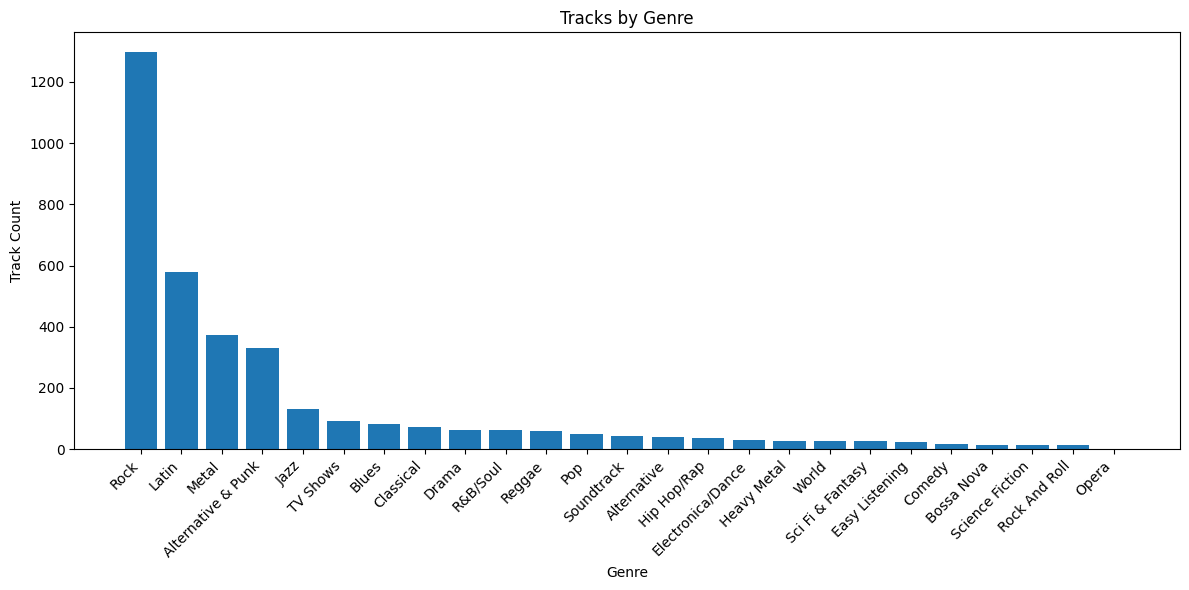

In [32]:

query = """
    SELECT g.Name, COUNT(t.TrackId) AS TrackCount
    FROM genres g
    LEFT JOIN tracks t ON g.GenreId = t.GenreId
    GROUP BY g.GenreId, g.Name
    ORDER BY TrackCount DESC;
"""

with closing(db.connect("chinook.db")) as db_con:
    genre_data = pd.read_sql_query(query, db_con)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(genre_data['Name'], genre_data['TrackCount'])
plt.xlabel('Genre')
plt.ylabel('Track Count')
plt.title('Tracks by Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## EXTRA CREDIT:
* Use a CTE
* Use a query that joins two or more tables.
* Make a model to see if you can predict something ( e.g. GNB classifier, linear regression )
* Come up with something else cool to do with your data


CTE

In [33]:
query = """
    WITH playlist_tracks AS (
        SELECT
            p.PlaylistId,
            p.Name AS PlaylistName,
            t.TrackId,
            t.Name AS TrackName,
            t.GenreId,
            t.Milliseconds,
            t.Bytes
        FROM playlists p
        JOIN playlist_track pt ON p.PlaylistId = pt.PlaylistId
        JOIN tracks t ON pt.TrackId = t.TrackId
    )
    SELECT *
    FROM playlist_tracks
    LIMIT 10;
"""

with closing(db.connect("chinook.db")) as db_con:
    df = pd.read_sql_query(query, db_con)
df

,PlaylistId,PlaylistName,TrackId,TrackName,GenreId,Milliseconds,Bytes
0,1,Music,1,For Those About To Rock (We Salute You),1,343719,11170334
1,8,Music,1,For Those About To Rock (We Salute You),1,343719,11170334
2,17,Heavy Metal Classic,1,For Those About To Rock (We Salute You),1,343719,11170334
3,1,Music,2,Balls to the Wall,1,342562,5510424
4,8,Music,2,Balls to the Wall,1,342562,5510424
5,17,Heavy Metal Classic,2,Balls to the Wall,1,342562,5510424
6,1,Music,3,Fast As a Shark,1,230619,3990994
7,5,90’s Music,3,Fast As a Shark,1,230619,3990994
8,8,Music,3,Fast As a Shark,1,230619,3990994
9,17,Heavy Metal Classic,3,Fast As a Shark,1,230619,3990994


### Join tables playlist_track and tracksID left join

In [34]:
query = """
    SELECT
        pt.PlaylistId,
        t.TrackId,
        t.Name,
        t.GenreId,
        t.Milliseconds
    FROM playlist_track pt
    JOIN tracks t ON pt.TrackId = t.TrackId
    LIMIT 10;
"""

with closing(db.connect("chinook.db")) as db_con:
    df = pd.read_sql_query(query, db_con)
df

,PlaylistId,TrackId,Name,GenreId,Milliseconds
0,1,1,For Those About To Rock (We Salute You),1,343719
1,8,1,For Those About To Rock (We Salute You),1,343719
2,17,1,For Those About To Rock (We Salute You),1,343719
3,1,2,Balls to the Wall,1,342562
4,8,2,Balls to the Wall,1,342562
5,17,2,Balls to the Wall,1,342562
6,1,3,Fast As a Shark,1,230619
7,5,3,Fast As a Shark,1,230619
8,8,3,Fast As a Shark,1,230619
9,17,3,Fast As a Shark,1,230619


In [35]:
query = '''
SELECT PlaylistId, TrackId, Name, Composer, UnitPrice
FROM playlist_track
JOIN tracks USING (TrackId)
LIMIT 25;

'''
with closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query(query, db_con)

df


,PlaylistId,TrackId,Name,Composer,UnitPrice
0,1,1,For Those About To Rock (We Salute You),"Angus Young, Malcolm Young, Brian Johnson",0.99
1,8,1,For Those About To Rock (We Salute You),"Angus Young, Malcolm Young, Brian Johnson",0.99
2,17,1,For Those About To Rock (We Salute You),"Angus Young, Malcolm Young, Brian Johnson",0.99
3,1,2,Balls to the Wall,None,0.99
4,8,2,Balls to the Wall,None,0.99
5,17,2,Balls to the Wall,None,0.99
6,1,3,Fast As a Shark,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",0.99
7,5,3,Fast As a Shark,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",0.99
8,8,3,Fast As a Shark,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",0.99
9,17,3,Fast As a Shark,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",0.99


### Create a model This is a Structured Data Set with continous values will run a GNB and Regression model

In [36]:
query = """
    SELECT
        c.CustomerId,
        c.Country,
        COUNT(DISTINCT i.InvoiceId) AS NumInvoices,
        COUNT(ii.InvoiceLineId) AS NumLineItems,
        SUM(ii.UnitPrice * ii.Quantity) AS TotalSpend
    FROM customers c
    JOIN invoices i ON c.CustomerId = i.CustomerId
    JOIN invoice_items ii ON i.InvoiceId = ii.InvoiceId
    GROUP BY c.CustomerId, c.Country;
"""

with closing(db.connect("chinook.db")) as db_con:
    customer_df = pd.read_sql_query(query, db_con)
customer_df.head()

,CustomerId,Country,NumInvoices,NumLineItems,TotalSpend
0,1,Brazil,7,38,39.62
1,2,Germany,7,38,37.62
2,3,Canada,7,38,39.62
3,4,Norway,7,38,39.62
4,5,Czech Republic,7,38,40.62


## Fetures and Target

 'NumInvoices and NumLineItems excluding target y = 'TotalSpend' to avoid training on y.  Target y = How much money a customer spent. Features what help predict the y.  Features what innvoices and items purchased.    For Regression model Mean spend is 37.619 and for classifications GNB we have 1 for high spenders and 0 for low spenders.
High spenders: 28 | Low spenders: 31


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import numpy as np

# Features (X) = behavior. Target excluded to prevent leakage.
X = customer_df[['NumInvoices', 'NumLineItems']].copy()

# --- REGRESSION target: continuous spend ---
y_reg = customer_df['TotalSpend']

# --- CLASSIFICATION target: binary high_spender (median split) ---
median_spend = customer_df['TotalSpend'].median()
y_clf = (customer_df['TotalSpend'] > median_spend).astype(int)

print("Median spend:", median_spend)
print("High spenders:", y_clf.sum(), "| Low spenders:", (y_clf==0).sum())

Median spend: 37.61999999999999
High spenders: 28 | Low spenders: 31


Running regression to determine gaps in prediction - the Dummy R2 is - 0.136 and the Liner Reggression is -0.1259 - the model is not performing well and is selecting for fetures that are mostly the same - there is not much variance in the data set features of customers.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.25, random_state=42)

# Dummy baseline first
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
print("Dummy R²:", r2_score(y_test, dummy.predict(X_test)))

# Real model
lr = LinearRegression()
lr.fit(X_train, y_train)
print("LinearRegression R²:", r2_score(y_test, lr.predict(X_test)))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr.predict(X_test))))

Dummy R²: -0.13644176468988323
LinearRegression R²: -0.12593697671632564
RMSE: 4.1814531215020665


Running GNB using DummyClassifier most frequent and see if the model can beat accuracy the stratifyy_clf for balanced.- no difference then the regression model - sklearn encountered a divide by zero - DB is too uniformed without much variance to make a good prediction with Regression or GNB

In [39]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.25, random_state=42, stratify=y_clf)

dummy_c = DummyClassifier(strategy='most_frequent')
dummy_c.fit(Xc_train, yc_train)
print("Dummy accuracy:", accuracy_score(yc_test, dummy_c.predict(Xc_test)))

gnb = GaussianNB()
gnb.fit(Xc_train, yc_train)
print("GNB accuracy:", accuracy_score(yc_test, gnb.predict(Xc_test)))

Dummy accuracy: 0.5333333333333333
GNB accuracy: 0.5333333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:513: RuntimeWarning: divide by zero encountered in log
  n_ij = -0.5 * np.sum(np.log(2.0 * np.pi * self.var_[i, :]))
/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:514: RuntimeWarning: divide by zero encountered in divide
  n_ij -= 0.5 * np.sum(((X - self.theta_[i, :]) ** 2) / (self.var_[i, :]), 1)
/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:514: RuntimeWarning: invalid value encountered in divide
  n_ij -= 0.5 * np.sum(((X - self.theta_[i, :]) ** 2) / (self.var_[i, :]), 1)
/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:514: RuntimeWarning: invalid value encountered in subtract
  n_ij -= 0.5 * np.sum(((X - self.theta_[i, :]) ** 2) / (self.var_[i, :]), 1)
